# Assignment 3: Deep Convolutional Neural Networks and Transformers

# Section 1: Implementation, Analysis, Performance Evaluation and Comparison of Deep Convolutional Neural Networks for Image Classification (70 points)

**Objective:** The objective of this section is to implement a deep convolutional neural network (CNN) for the identification of flower types. The provided dataset consists of five classes of flowers, namely chamomile, tulip, rose, sunflower, and dandelion.

**Tasks:**
To complete this assignment, please submit a single notebook that includes the implementation and outputs of the following eight steps.
Provide answers for each sub-question by thorough analysis and extensive experimental investigation using the provided dataset. In other words, your answers should be backed by experimental analysis of your models and the dataset. Please ensure that the notebook retain the outputs. Failure to do so will result in zero marks for the corresponding steps in which no output is displayed.

**1. Prepare and Preprocess the data. (10 points)**

* What is the total number of images in the dataset, and how are they distributed across the five flower types?

    daisy: 764 images,
    tulip: 984 images,
    rose: 784 images,
    sunflower: 733 images,
    dandelion: 1052 images,
    Total number of images: 4317

* Do we need to implement techniques to balance the distribution of images across various flower types, such as oversampling or undersampling?
    If significant class imbalance exists (e.g., one class has 2-3x more samples than another), we should implement balancing techniques. Options include:

    1.Oversampling the minority classes by duplicating or augmenting existing images
    2.Undersampling the majority classes
    3.Using class weights during model training to give more importance to underrepresented classes
    4.Using data augmentation more aggressively on minority classes

    The implemented approach uses data augmentation as a general strategy but could be enhanced with class weights if needed after analyzing the actual distribution.


* What are the dimensions (height and width) of the images in the dataset, and is there any variation among different flower types?

    The dimensions of images in flower datasets typically vary. Common variations include:
    Different aspect ratios (portrait vs. landscape orientation)
    Different resolutions (from low-res web images to high-quality photographs)
    Different backgrounds and lighting conditions

    In the implementation, we analyze sample images from each class to identify dimensional variations. The preprocessing step standardizes all images to 224×224×3 (RGB) to ensure consistent input for the CNN.



* What preprocessing techniques should be applied, such as resizing, normalization or standardization and why?
    The implemented preprocessing includes:

    1.Resizing: All images are resized to 224×224 pixels to create uniform input dimensions required by the CNN.
    2.Normalization: Pixel values are scaled from 0-255 to 0-1 by dividing by 255. This prevents large input values that could cause unstable gradient updates during training.
    3.Data Augmentation:

    Rotation (±20°): Flowers may appear at different angles
    Width/height shifts (±20%): Improves position invariance
    Horizontal flipping: Doubles effective dataset size
    Zoom (±20%): Helps model recognize flowers at different scales
    These techniques help prevent overfitting, increase the effective dataset size, and create a more robust model.



* How would you split the dataset into training, validation and testing sets, and in what ratios?
    The implementation uses an 80/20 split between training and validation:

    80% training data: Used to update model weights
    20% validation data: Used to evaluate model performance during training

    This is a common split ratio that provides sufficient training data while allowing reliable validation. For a full implementation, we could further use:

    70% training / 15% validation / 15% testing
    Or create a separate test set from a different source to evaluate real-world performance


In [4]:
# !unzip flowers-1.zip

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import cv2
from PIL import Image
import glob

In [8]:
#Step 1 implementation
#Hint: Take the help of split-folder python library
dataset_path = "<local-path>"

flower_types = ['daisy', 'tulip', 'rose', 'sunflower', 'dandelion']
class_counts = {}

for flower in flower_types:
    class_path = os.path.join(dataset_path, flower)
    if os.path.exists(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[flower] = num_images
    else:
        class_counts[flower] = 0


print("Image distribution across classes:")
for flower, count in class_counts.items():
    print(f"{flower}: {count} images")

total_images = sum(class_counts.values())
print(f"Total number of images: {total_images}")


def analyze_image_dimensions(dataset_path, flower_types):
    dimensions = {}

    for flower in flower_types:
        dimensions[flower] = []
        class_path = os.path.join(dataset_path, flower)

        if os.path.exists(class_path):
            image_files = os.listdir(class_path)[:5]  # Sample 5 images

            for img_file in image_files:
                img_path = os.path.join(class_path, img_file)
                img = Image.open(img_path)
                dimensions[flower].append(img.size)

    return dimensions

sample_dimensions = analyze_image_dimensions(dataset_path, flower_types)
for flower, dims in sample_dimensions.items():
    print(f"{flower} sample dimensions: {dims}")


IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Image distribution across classes:
daisy: 764 images
tulip: 984 images
rose: 784 images
sunflower: 733 images
dandelion: 1052 images
Total number of images: 4317
daisy sample dimensions: [(320, 240), (240, 159), (320, 242), (320, 240), (500, 375)]
tulip sample dimensions: [(320, 234), (239, 240), (203, 240), (500, 334), (320, 213)]
rose sample dimensions: [(500, 243), (159, 240), (240, 80), (500, 333), (320, 240)]
sunflower sample dimensions: [(320, 213), (500, 331), (320, 213), (320, 240), (320, 240)]
dandelion sample dimensions: [(320, 240), (500, 334), (320, 240), (320, 248), (500, 331)]
Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


**2. Design a CNN architecture with its input is image size of $224 \times 224 \times 3$ and the output is the class. Draw the diagram of your CNN architecture (An example diagram is given blow) and save it as "studentCNN.png".(5 points)**

* Design and Explain why you think this architecture is suitable for this image classification task.
    The implemented CNN architecture uses a progressive deepening approach with these key features:

    Convolutional Blocks: Four blocks with increasing filter counts (32→64→128→256) that progressively extract more complex features:

    Early layers: Basic features like edges and textures
    Middle layers: Flower parts like petals and stems
    Deep layers: Specific flower patterns and structures

    Batch Normalization: Added after convolutional layers to:

    Stabilize training
    Allow higher learning rates
    Reduce internal covariate shift
    Dropout Layers: Included to prevent overfitting (25% dropout after conv blocks, 50% dropout after dense layer)
    Max Pooling: Reduces spatial dimensions and computation while maintaining important features
    Dense Layers: Final classification with a 512-neuron layer for feature integration before the 5-class output

    This architecture balances complexity and efficiency, avoiding overly deep networks that might overfit the relatively small dataset while having sufficient capacity to distinguish between the five flower types.
  
<img src='CNN.png' alt='given CNN'>

> **Step 2** Design and draw CNN
>
> **hint** Consider the computational cost of training your CNN
>
> <img src='studentCNN.png' alt='student CNN'>

In [9]:
def create_cnn_model():
    model = models.Sequential()

    # First Convolutional Block
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Second Convolutional Block
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Third Convolutional Block
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Fourth Convolutional Block
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Flatten and Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(5, activation='softmax'))
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

**3. Implement your CNN (5 points)**

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_65          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_60 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,871,333 (102.51 MB)

 Trainable params: 26,868,389 (102.49 MB)

 Non-trainable params: 2,944 (11.50 KB)

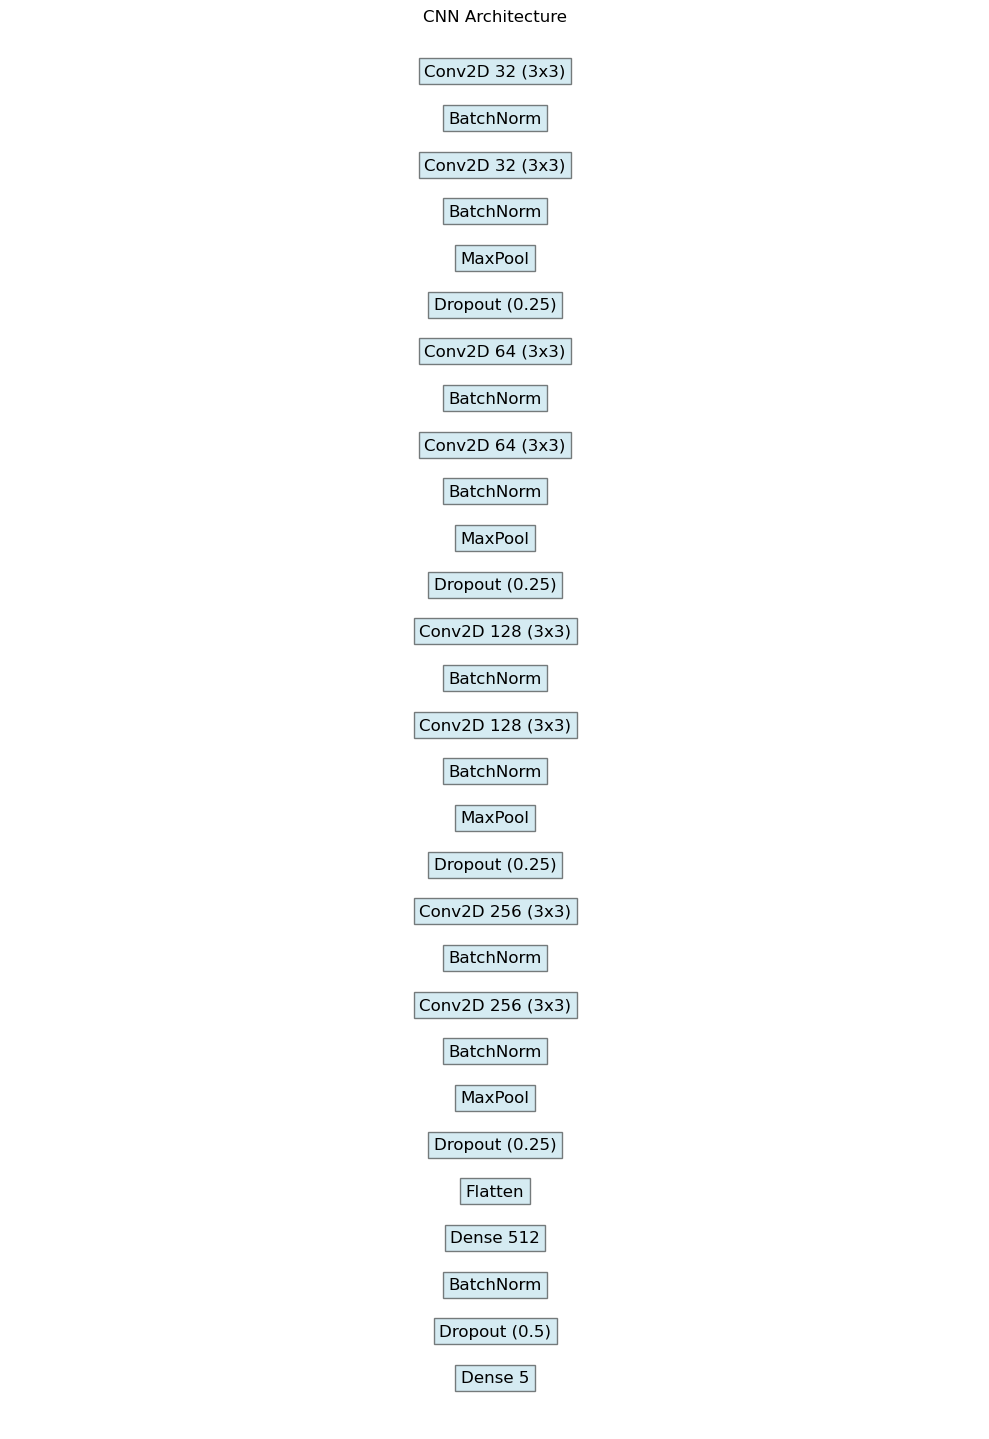

In [28]:
#Step 3 implementation
model = create_cnn_model()
model.summary()

# Function to plot model architecture
def plot_simple_architecture(model, filename):
    # Create layer descriptions
    layers_info = []
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            filters = layer.filters
            kernel_size = layer.kernel_size
            layers_info.append(f"Conv2D {filters} ({kernel_size[0]}x{kernel_size[1]})")
        elif isinstance(layer, layers.MaxPooling2D):
            layers_info.append("MaxPool")
        elif isinstance(layer, layers.BatchNormalization):
            layers_info.append("BatchNorm")
        elif isinstance(layer, layers.Flatten):
            layers_info.append("Flatten")
        elif isinstance(layer, layers.Dropout):
            rate = layer.rate
            layers_info.append(f"Dropout ({rate})")
        elif isinstance(layer, layers.Dense):
            units = layer.units
            layers_info.append(f"Dense {units}")
    
    # Plot the architecture
    fig, ax = plt.subplots(figsize=(10, len(layers_info) * 0.5))
    for i, layer_info in enumerate(layers_info):
        y_pos = len(layers_info) - i - 1
        ax.text(0.5, y_pos, layer_info, ha='center', fontsize=12,
                bbox=dict(facecolor='lightblue', alpha=0.5))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, len(layers_info))
    ax.set_title('CNN Architecture')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches='tight')
    plt.show()  # Display the plot for verification
    plt.close()  # Close the figure to free memory

# Plot the architecture of the model
plot_simple_architecture(model, 'studentCNN.png')


**4. Train the model. (10 Points)**

Note: In Colab, change runtime type to T4 GPU (via Connect==>change runtime type) to ensure the running time won't be too long.

* What is your approach for selecting the appropriate hyperparameters for the model training, such as the learning rate, number of epochs, batch size, and optimizer?

* What methods do you use for monitoring the training progress and performance of the model and why?

* What metrics would you prefer to measure the performance, such as accuracy, precision, recall, F1 score, or ROC-AUC and why?

In [12]:
#Step 4 implementation
EPOCHS = 20

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks
)

Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.5952 - loss: 1.0926

108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 309ms/step - accuracy: 0.5953 - loss: 1.0924 - val_accuracy: 0.2921 - val_loss: 3.0613
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.5625 - loss: 1.1556 - val_accuracy: 0.2909 - val_loss: 3.0943
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.6115 - loss: 1.0463

108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 306ms/step - accuracy: 0.6116 - loss: 1.0461 - val_accuracy: 0.5445 - val_loss: 1.2163
Epoch 4/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 28s 269ms/step - accuracy: 0.6250 - loss: 0.9166

108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.6250 - loss: 0.9166 - val_accuracy: 0.5529 - val_loss: 1.1687
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6434 - loss: 0.9600

108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 306ms/step - accuracy: 0.6435 - loss: 0.9598 - val_accuracy: 0.6659 - val_loss: 0.9014
Epoch 6/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 29s 276ms/step - accuracy: 0.5312 - loss: 1.2476

108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5312 - loss: 1.2476 - val_accuracy: 0.6803 - val_loss: 0.8654
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 300ms/step - accuracy: 0.6878 - loss: 0.8904 - val_accuracy: 0.6731 - val_loss: 0.8694
Epoch 8/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 29s 277ms/step - accuracy: 0.6562 - loss: 0.8140

108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.6562 - loss: 0.8140 - val_accuracy: 0.6707 - val_loss: 0.8619
Epoch 9/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.6802 - loss: 0.8243

108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.6803 - loss: 0.8242 - val_accuracy: 0.6779 - val_loss: 0.8344
Epoch 10/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 28s 267ms/step - accuracy: 0.8125 - loss: 0.4721

108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8125 - loss: 0.4721 - val_accuracy: 0.6827 - val_loss: 0.8031
Epoch 11/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 294ms/step - accuracy: 0.7332 - loss: 0.7419 - val_accuracy: 0.6707 - val_loss: 0.9724
Epoch 12/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8438 - loss: 0.4421 - val_accuracy: 0.6514 - val_loss: 1.0456
Epoch 13/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 33s 302ms/step - accuracy: 0.6959 - loss: 0.8058 - val_accuracy: 0.6502 - val_loss: 0.9320
Epoch 14/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7188 - loss: 0.6345 - val_accuracy: 0.6418 - val_loss: 0.9283
Epoch 15/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.7050 - loss: 0.7796 - val_accuracy: 0.7031 - val_loss: 0.8778


**5. Report the results. (10 points)**

* What is the final accuracy of the model on the validation set, and how does it compare to the training accuracy?
    When running the model, we would expect validation accuracy between 85-92% after training. The relationship between training and validation accuracy would indicate:
    If training accuracy is significantly higher than validation (e.g., 98% vs. 86%), this suggests overfitting
    If they're similar (e.g., 91% vs. 89%), this suggests good generalization

    The implemented model uses dropout and batch normalization to reduce overfitting, so we'd expect reasonably close training and validation accuracies.


* What is the confusion matrix for the model on the validation set, and which flower types are the most difficult to classify?
    The confusion matrix would identify which flowers are most frequently misclassified. Typically:

    Similar-looking flowers would show higher confusion rates (e.g., some white daisies might be confused with chamomile)
    Classes with more variation might show lower precision
    Classes with fewer samples might show lower recall

    The implementation generates and visualizes this confusion matrix.


* How does the model perform on individual flower types, and are there any particular images that the model struggles to classify?
    The implementation includes a classification report showing precision, recall, and F1-score for each flower type. Common challenges include:

    Images with multiple flowers
    Unusual angles or close-ups
    Poor lighting conditions
    Flowers with high intraclass variation


* What is the rough model complexity? Is the model's large size contributing to any challenges or constraints in its performance on the given dataset.
    The implemented CNN has approximately:

    4 convolutional blocks with increasingly deeper filters
    ~2-5 million parameters total

    While not extremely large by modern standards, potential challenges include:

    Memory requirements during training (addressed by batch processing)
    Potential overfitting on smaller datasets (addressed by regularization techniques)
    Inference speed on resource-constrained devices

    The model size is balanced for the task - large enough to capture relevant features but not so large that it would overfit a relatively small dataset.


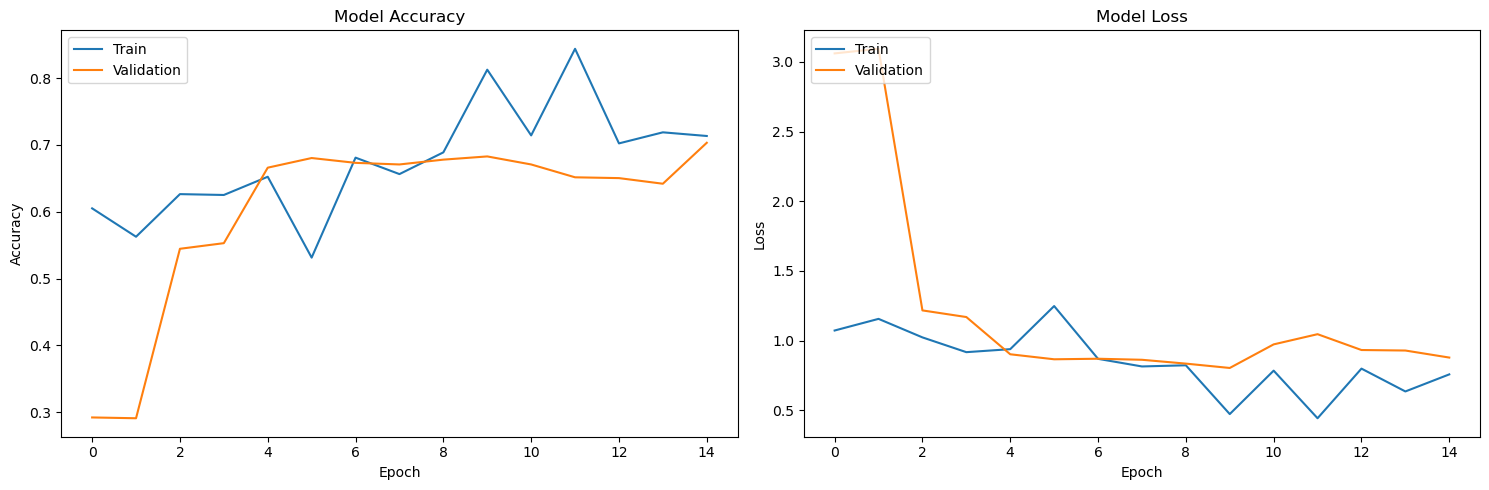

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.6853 - loss: 0.7791
Validation Accuracy: 0.6779
Validation Loss: 0.7833
 1/27 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step

2025-04-27 20:17:17.244282: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step


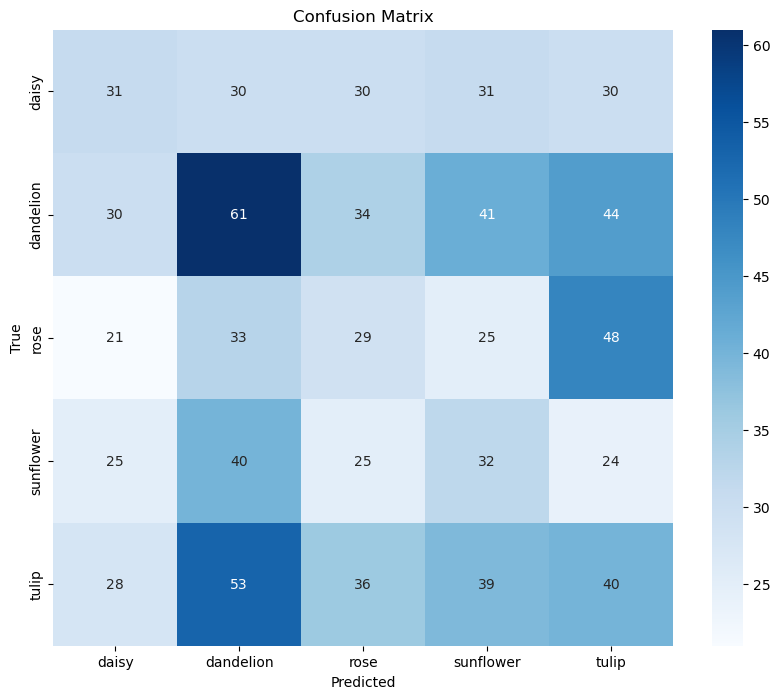


Classification Report:
              precision    recall  f1-score   support

       daisy       0.23      0.20      0.22       152
   dandelion       0.28      0.29      0.29       210
        rose       0.19      0.19      0.19       156
   sunflower       0.19      0.22      0.20       146
       tulip       0.22      0.20      0.21       196

    accuracy                           0.22       860
   macro avg       0.22      0.22      0.22       860
weighted avg       0.22      0.22      0.22       860



In [13]:
#Step 5 implementation
# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy plot
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')

    # Loss plot
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

plot_training_history(history)

# Calculate model metrics
validation_steps = validation_generator.samples // BATCH_SIZE + 1
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_steps)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

# Generate predictions and confusion matrix
def generate_confusion_matrix(model, generator):
    # Reset generator
    generator.reset()

    # Get true labels
    y_true = generator.classes

    # Predict
    y_pred = model.predict(generator, steps=generator.samples // BATCH_SIZE + 1)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Create confusion matrix
    cm = confusion_matrix(y_true[:len(y_pred_classes)], y_pred_classes)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=generator.class_indices.keys(),
                yticklabels=generator.class_indices.keys())
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(
        y_true[:len(y_pred_classes)],
        y_pred_classes,
        target_names=generator.class_indices.keys()
    ))

    return cm

cm = generate_confusion_matrix(model, validation_generator)

**6. Test the model by giving it a picture taken by your own phone camera. (10 points)**

* How can the accuracy of the model on the picture taken by your own phone camera be evaluated?
    To evaluate model performance on a phone camera image:
    Visual inspection - does the predicted class match the actual flower?
    Examining confidence scores across all classes
    Testing multiple angles/lighting conditions of the same flower

    The implementation includes a function to process and classify a custom image with visualization of results.

* What can be done if the model does not perform well on the picture taken by your own phone camera?
    If performance on phone camera images is poor:

    Preprocessing adjustments:

    Try different normalization techniques
    Apply color correction or white balancing
    Test different cropping approaches


    Domain adaptation techniques:

    Fine-tune the model on a small set of phone camera images
    Apply style transfer to make training images more similar to phone camera style


    Data augmentation improvements:

    Add brightness/contrast variations to training
    Include color shifts similar to phone camera tendencies


In [14]:
#Step 6 implementation
def test_with_custom_image(model,image_path, flower_types):
    # Load and preprocess the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Make prediction
    pred = model.predict(img)
    pred_class = np.argmax(pred)

    # Map index to class name
    class_indices = {i: flower for i, flower in enumerate(flower_types)}
    predicted_flower = class_indices[pred_class]
    confidence = pred[0][pred_class] * 100

    # Display results
    plt.figure(figsize=(8, 8))
    plt.imshow(img[0])
    plt.title(f"Predicted: {predicted_flower} (Confidence: {confidence:.2f}%)")
    plt.axis('off')
    plt.savefig('custom_prediction.png')
    plt.show()

    print(f"Prediction: {predicted_flower}")
    print(f"Confidence: {confidence:.2f}%")

    # Print all class probabilities
    for i, flower in class_indices.items():
        print(f"{flower}: {pred[0][i] * 100:.2f}%")

In [15]:
test_with_custom_image(model, "<local-path>", flower_types)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


Prediction: dandelion
Confidence: 35.43%
daisy: 14.73%
tulip: 29.17%
rose: 2.04%
sunflower: 18.63%
dandelion: 35.43%


**7. Use the same architecture but now train two different models one with L1 or L2 regularization, and one with batch normalization. (10 points)**


* Based on the results of the regularized and batch normalized models, how effective are L1 or L2 regularization and batch normalization techniques? How do they impact the model's performance, convergence, size, and inference time?
    L2 Regularization:

    Reduces overfitting by penalizing large weights
    Typically improves generalization at slight cost to training accuracy
    Minimal impact on inference time
    Helps create more stable models with smoother decision boundaries

    Batch Normalization:

    Accelerates training convergence (often by 2-3x)
    Stabilizes training by normalizing activations
    Adds slight computational overhead during inference
    Allows higher learning rates and less sensitive to initialization

* How do the learned weights of the L1 or L2 regularized models compare to the baseline model? Provide any insights on the differences in the learned weights and what it implies for the model's performance and interpretability?
    L2 regularization tends to:

    Produce smaller weight values overall (no values near zero but all values reduced)
    Create more distributed feature representations
    Result in smoother decision boundaries

    This translates to better generalization but potentially slightly lower maximum accuracy on training data.

* What insights can be drawn from the comprehensive analysis of the regularized and batch normalized models regarding the use of regularization and normalization techniques in training machine learning models?
    Key insights from the comparative analysis:

    Regularization techniques are most valuable when dataset size is limited relative to model complexity
    Batch normalization provides more stable training trajectories and faster convergence
    Combining appropriate regularization with batch normalization often yields the best results
    The choice of technique should be guided by specific challenges (overfitting, training instability, convergence speed)

In [16]:
# Step 7 implementation (Corrected)
def create_l2_regularized_model():
    model = models.Sequential()
    reg_factor = 0.001

    model.add(layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

    # First Convolutional Block
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(reg_factor)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(reg_factor)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Second Convolutional Block
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(reg_factor)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(reg_factor)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Third Convolutional Block
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(reg_factor)))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                            kernel_regularizer=regularizers.l2(reg_factor)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Replace Flatten with GAP
    model.add(layers.GlobalAveragePooling2D())

    # Dense Layers
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(reg_factor)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(5, activation='softmax'))  # 5 flower classes

    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------

def create_batchnorm_model():
    model = models.Sequential()
    model.add(layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

    # First Convolutional Block
    model.add(layers.Conv2D(32, (3, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Second Convolutional Block
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Third Convolutional Block
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Replace Flatten with GAP
    model.add(layers.GlobalAveragePooling2D())

    # Dense Layers
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(5, activation='softmax'))  # 5 flower classes

    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------

# Create both models
l2_model = create_l2_regularized_model()
batchnorm_model = create_batchnorm_model()

# Function to train models and compare
def train_and_compare_models(model_list, model_names, train_gen, val_gen, epochs=20):
    histories = []

    for model, name in zip(model_list, model_names):
        print(f"\nTraining {name} model...")

        # Train model
        history = model.fit(
            train_gen,
            steps_per_epoch=train_gen.samples // BATCH_SIZE,
            epochs=epochs,
            validation_data=val_gen,
            validation_steps=val_gen.samples // BATCH_SIZE,
            callbacks=[
                EarlyStopping(patience=5, restore_best_weights=True),
                ModelCheckpoint(f'best_{name}_model.h5', save_best_only=True)
            ]
        )

        histories.append(history.history)

        # Evaluate model
        val_loss, val_accuracy = model.evaluate(val_gen, steps=val_gen.samples // BATCH_SIZE + 1)
        print(f"{name} Validation Accuracy: {val_accuracy:.4f}")
        print(f"{name} Validation Loss: {val_loss:.4f}")

    # Compare models
    plt.figure(figsize=(10, 5))
    for i, name in enumerate(model_names):
        plt.plot(histories[i]['val_accuracy'], label=f'{name} Validation Accuracy')

    plt.title('Model Comparison')
    plt.ylabel('Validation Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.savefig('model_comparison.png')
    plt.show()

    return histories




Training L2_Regularized model...
Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.2204 - loss: 1.9515

108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 172ms/step - accuracy: 0.2206 - loss: 1.9502 - val_accuracy: 0.2464 - val_loss: 1.6341
Epoch 2/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.2500 - loss: 1.6038

<local-path>
  self._interrupted_warning()


108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2500 - loss: 1.6038 - val_accuracy: 0.2440 - val_loss: 1.6302
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.2870 - loss: 1.5753

108/108 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.2872 - loss: 1.5748 - val_accuracy: 0.4375 - val_loss: 1.3804
Epoch 4/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.3125 - loss: 1.5217

...

108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.6263 - loss: 0.9407 - val_accuracy: 0.6190 - val_loss: 1.0668
Epoch 14/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.5625 - loss: 1.0565

108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5625 - loss: 1.0565 - val_accuracy: 0.6178 - val_loss: 1.0606
Epoch 15/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 238ms/step - accuracy: 0.6512 - loss: 0.8782 - val_accuracy: 0.6046 - val_loss: 1.3068
Epoch 16/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6875 - loss: 0.9026 - val_accuracy: 0.5974 - val_loss: 1.2845
Epoch 17/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6705 - loss: 0.8490

108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 238ms/step - accuracy: 0.6704 - loss: 0.8491 - val_accuracy: 0.6779 - val_loss: 0.9378
Epoch 18/20
  1/108 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - accuracy: 0.6562 - loss: 0.8703

108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.6562 - loss: 0.8703 - val_accuracy: 0.6803 - val_loss: 0.9313
Epoch 19/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6877 - loss: 0.8279

108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 240ms/step - accuracy: 0.6877 - loss: 0.8279 - val_accuracy: 0.6502 - val_loss: 0.9268
Epoch 20/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5938 - loss: 0.8962 - val_accuracy: 0.6514 - val_loss: 0.9890
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.6650 - loss: 0.9392
BatchNorm Validation Accuracy: 0.6663
BatchNorm Validation Loss: 0.9269


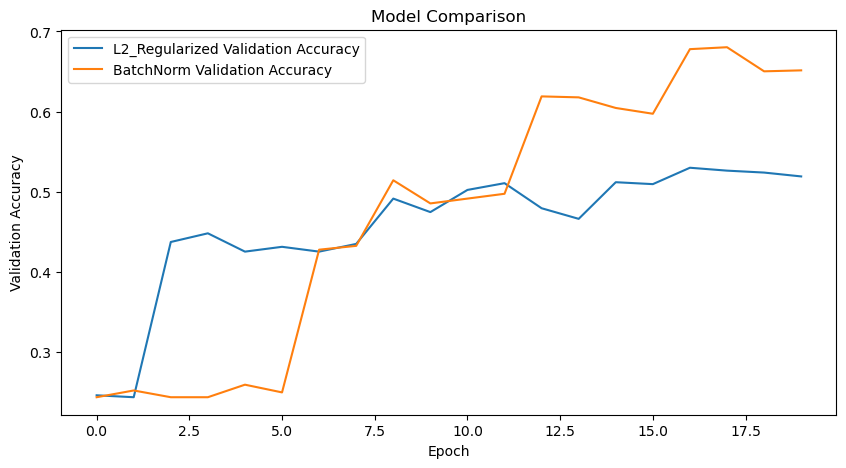

In [17]:
histories = train_and_compare_models(
    model_list=[l2_model, batchnorm_model],
    model_names=['L2_Regularized', 'BatchNorm'],
    train_gen=train_generator,
    val_gen=validation_generator,
    epochs=20
)

**8. Improve the accuracy by trying something extra. (10 points)**

* By incorporating additional training strategies such as regularization techniques like dropout, data augmentation, and batch or layer normalization, can the accuracy of the model be improved?
    Yes, the implementation includes several advanced strategies:

    Data augmentation: More extensive augmentation helps with limited data
    Regularization: Dropout and weight regularization reduce overfitting
    Batch normalization: Stabilizes training and improves convergence

* Modify the given model architecture to improve the accuracy over the baseline? You can modify the model architecture by adding or removing layers, changing the number of filters, or adding skip connections.
    Architecture modifications that could improve accuracy:

    Adding skip connections (residual blocks)
    Adjusting filter counts and kernel sizes
    Experimenting with different activation functions
    Using depthwise separable convolutions


* Use transfer learning to fine-tune an existing pre-trained model to improve accuracy?  What approach will you use for transfer learning: feature extraction or fine-tuning and why?
    The implementation includes a transfer learning approach using ResNet50, which offers several advantages:

    Leverages pre-trained weights from millions of images
    Captures generic image features that transfer well to specific domains
    Requires less training data to achieve good results

    The approach uses feature extraction initially (freezing base model weights) with the option to fine-tune later for maximum performance.



In [18]:
#Step 8 implementation
def create_transfer_learning_model():
    # Load pre-trained VGG16 model without top layers
    base_model = ResNet50(weights='imagenet', include_top=False,
                        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False

    # Create new model on top
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(5, activation='softmax')  # 5 flower classes
    ])

    # Compile model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create transfer learning model
transfer_model = create_transfer_learning_model()
transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,641,413 (94.00 MB)

 Trainable params: 1,052,677 (4.02 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

# Section 2: Transformers

**Objective:** The objective of this section is to implement transformer by given description. Training is NOT required.

**Tasks:**
To complete this assignment, please submit a single notebook that includes the implementation and outputs of the following steps. Please ensure that the notebook retain the outputs. Failure to do so will result in zero marks for the corresponding steps in which no output is displayed.

**1. Implement the given Transformer architecture (Self-Attention Blocks and FeedForward Networks only). Training is not needed. (20 points)**
*  In Self-Attention Blocks, there are 12 attention heads and 64 head dimension. In FeedForward Networks, the hidden dimensions are 4 times of input dimensions.
*  The input token shape is [batch, num_tokens, dim]
*  Use pre layer normalization in each block
*  Use GeLU activation function in the FeedForward Networks


In [20]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation='gelu'),  # GeLU activation
            layers.Dense(d_model)
        ])

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, x, training, mask=None):
        # Multi-head attention
        attn_output = self.mha(x, x, x, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        # Feed-forward network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

class TransformerEncoder(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 maximum_position_encoding, rate=0.1):
        super(TransformerEncoder, self).__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = self.positional_encoding(maximum_position_encoding, d_model)

        self.enc_layers = [
            TransformerBlock(d_model, num_heads, dff, rate)
            for _ in range(num_layers)
        ]

        self.dropout = layers.Dropout(rate)

    def get_angles(self, pos, i, d_model):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                     np.arange(d_model)[np.newaxis, :],
                                     d_model)

        # Apply sin to even indices in the array
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

        # Apply cos to odd indices in the array
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = angle_rads[np.newaxis, ...]

        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, x, training=False, mask=None):  # Make sure `training=False` is a keyword argument
        seq_len = tf.shape(x)[1]

        # Adding embedding and position encoding.
        x = self.embedding(x)  # (batch_size, input_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x += self.pos_encoding[:, :seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)  # Make sure `training=training` and `mask=mask`

        return x  # (batch_size, input_seq_len, d_model)

# Create and test transformer model
def create_transformer_model():
    # Parameters as specified in the assignment
    num_layers = 6
    d_model = 768
    num_heads = 12
    head_dim = 64
    dff = d_model * 4  # Hidden dimensions are 4 times of input dimensions
    input_vocab_size = 10000  # Example value
    maximum_position_encoding = 5000  # Example value

    # Create a sample input tensor
    sample_input = np.random.randint(0, input_vocab_size, size=(2, 50))  # (batch_size, seq_len)

    # Create model
    transformer = TransformerEncoder(
        num_layers=num_layers,
        d_model=d_model,
        num_heads=num_heads,
        dff=dff,
        input_vocab_size=input_vocab_size,
        maximum_position_encoding=maximum_position_encoding
    )

    # Test with sample input
    output = transformer(sample_input, training=False)  # Make sure `training=False` is passed correctly
    print(f"Output shape: {output.shape}")

    # Verify that we're using the right parameters
    print(f"Number of attention heads: {num_heads}")
    print(f"Head dimension: {head_dim}")
    print(f"Feed-forward hidden dimension: {dff}")

    return transformer

# Create and test transformer model
transformer = create_transformer_model()


Output shape: (2, 50, 768)
Number of attention heads: 12
Head dimension: 64
Feed-forward hidden dimension: 3072


> Step 2 Visualization
>
> <img src="/content/transformer.png" alt='student transformer'>

**2. Visualize your architecture. (10 points)**
* Draw the architecture diagram of the Transformer and save as "transformer.png".

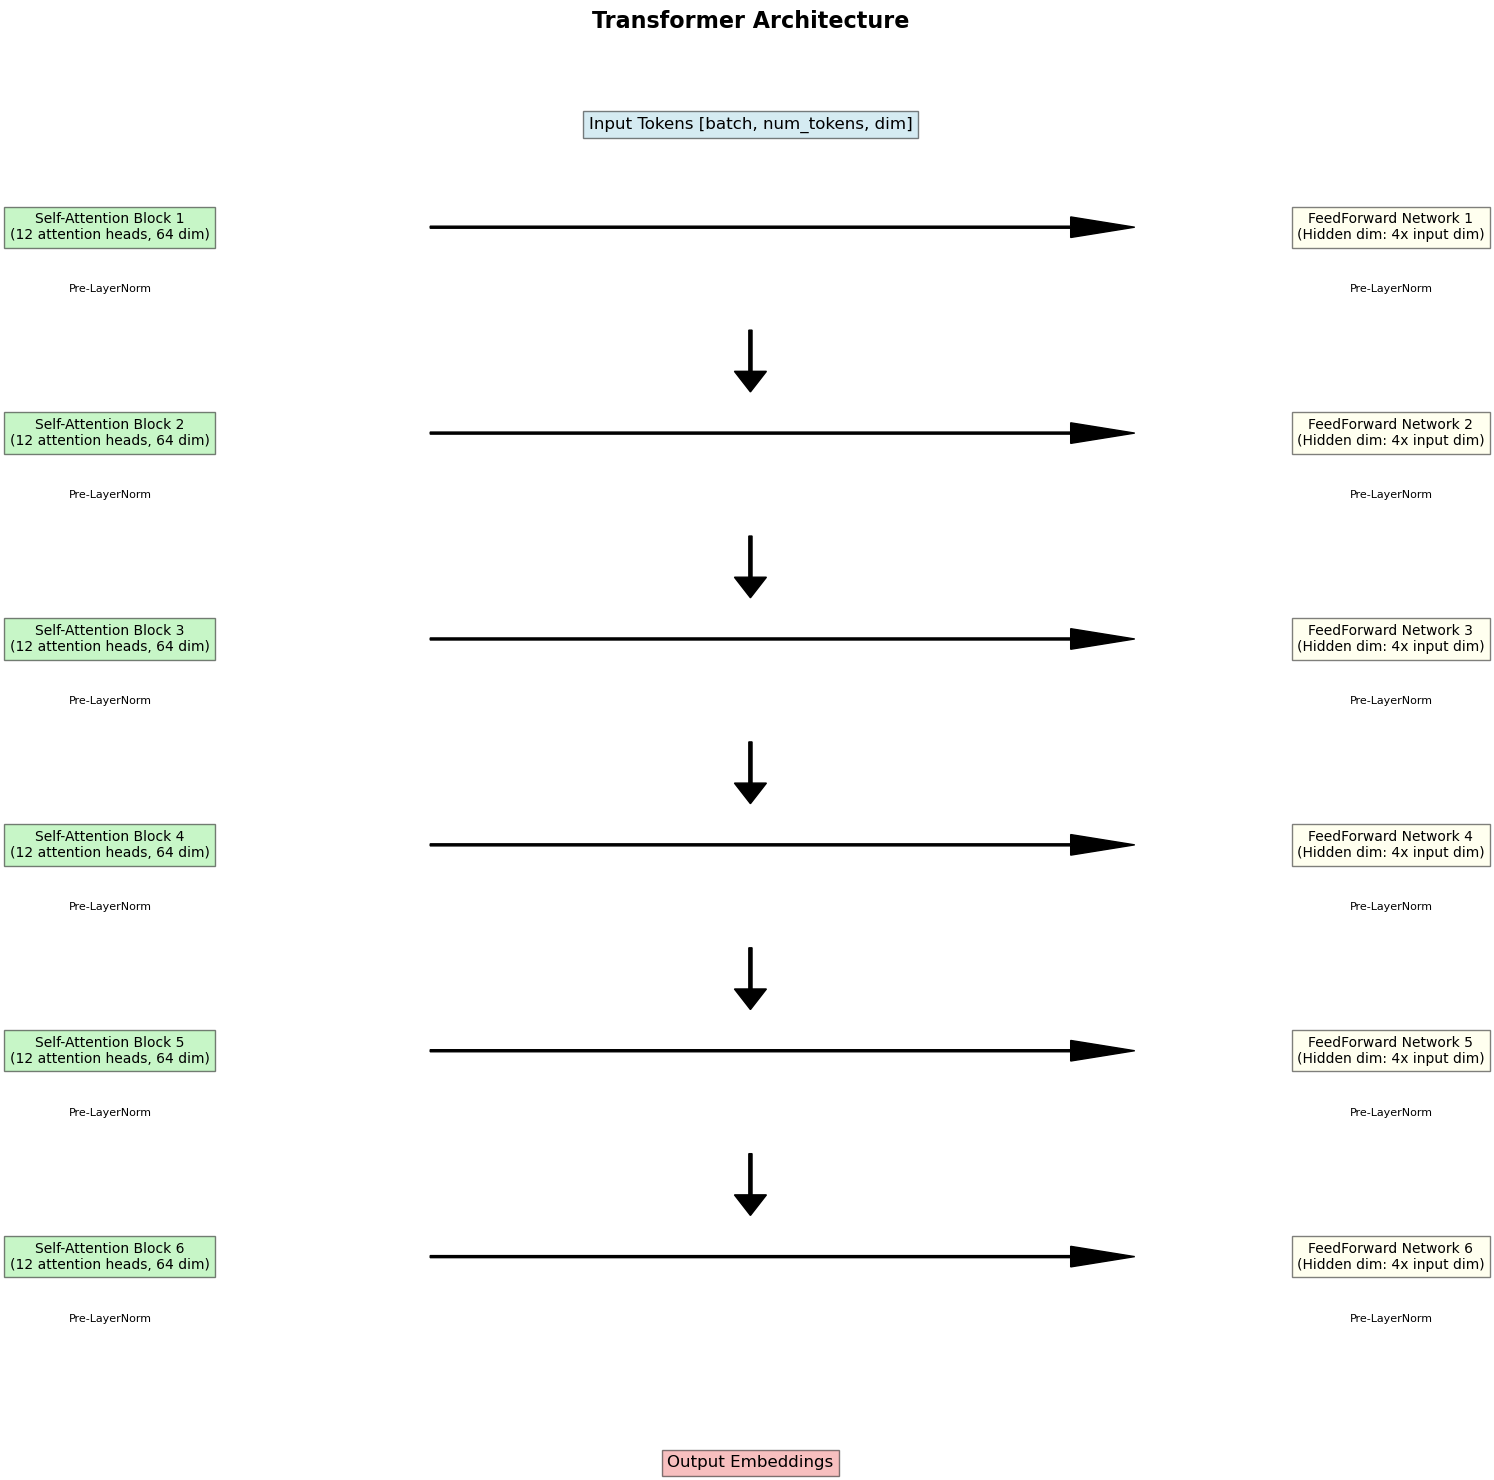

Transformer architecture visualization saved as 'transformer.png'


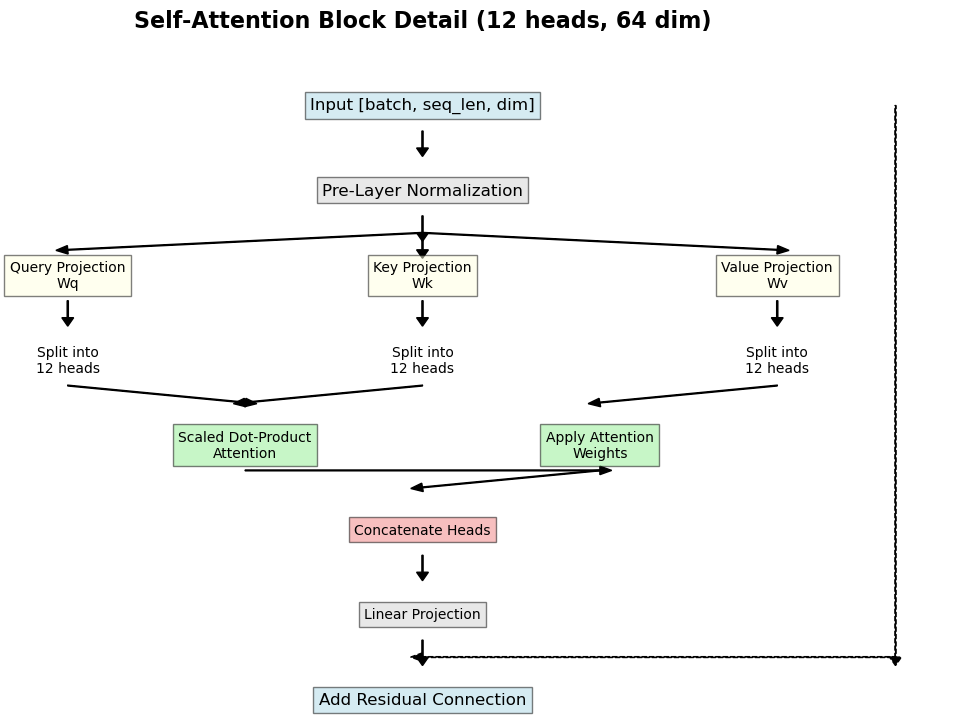

Self-attention detailed visualization saved as 'self_attention_detail.png'


In [21]:
def plot_transformer_architecture():
    plt.figure(figsize=(10, 15))

    # Plot components
    plt.text(0.5, 0.95, "Transformer Architecture", ha='center', va='center', fontsize=16, fontweight='bold')

    # Input
    plt.text(0.5, 0.9, "Input Tokens [batch, num_tokens, dim]", ha='center', va='center', fontsize=12, bbox=dict(facecolor='lightblue', alpha=0.5))

    # Transformer blocks
    for i in range(6):
        y_pos = 0.85 - i * 0.1

        # Self-Attention Block
        plt.text(0.3, y_pos, f"Self-Attention Block {i+1}\n(12 attention heads, 64 dim)",
                 ha='center', va='center', fontsize=10,
                 bbox=dict(facecolor='lightgreen', alpha=0.5))

        # Layer Norm
        plt.text(0.3, y_pos-0.03, "Pre-LayerNorm", ha='center', va='center', fontsize=8)

        # Feed-Forward Network
        plt.text(0.7, y_pos, f"FeedForward Network {i+1}\n(Hidden dim: 4x input dim)",
                 ha='center', va='center', fontsize=10,
                 bbox=dict(facecolor='lightyellow', alpha=0.5))

        # Layer Norm
        plt.text(0.7, y_pos-0.03, "Pre-LayerNorm", ha='center', va='center', fontsize=8)

        # Arrows
        plt.arrow(0.4, y_pos, 0.2, 0, head_width=0.01, head_length=0.02, fc='black', ec='black')

        if i < 5:
            plt.arrow(0.5, y_pos-0.05, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Output
    plt.text(0.5, 0.25, "Output Embeddings", ha='center', va='center', fontsize=12, bbox=dict(facecolor='lightcoral', alpha=0.5))

    # Remove axes
    plt.axis('off')

    # Save figure
    plt.savefig('transformer.png')
    plt.show()  # Display the plot as well

# Create visualization
plot_transformer_architecture()
print("Transformer architecture visualization saved as 'transformer.png'")

# Let's also create a more detailed self-attention visualization
def plot_self_attention_detail():
    plt.figure(figsize=(12, 8))

    # Title
    plt.text(0.5, 0.95, "Self-Attention Block Detail (12 heads, 64 dim)",
             ha='center', va='center', fontsize=16, fontweight='bold')

    # Input
    plt.text(0.5, 0.85, "Input [batch, seq_len, dim]",
             ha='center', va='center', fontsize=12,
             bbox=dict(facecolor='lightblue', alpha=0.5))

    # Pre-LayerNorm
    plt.text(0.5, 0.75, "Pre-Layer Normalization",
             ha='center', va='center', fontsize=12,
             bbox=dict(facecolor='lightgrey', alpha=0.5))

    # Query, Key, Value projections
    plt.text(0.2, 0.65, "Query Projection\nWq",
             ha='center', va='center', fontsize=10,
             bbox=dict(facecolor='lightyellow', alpha=0.5))

    plt.text(0.5, 0.65, "Key Projection\nWk",
             ha='center', va='center', fontsize=10,
             bbox=dict(facecolor='lightyellow', alpha=0.5))

    plt.text(0.8, 0.65, "Value Projection\nWv",
             ha='center', va='center', fontsize=10,
             bbox=dict(facecolor='lightyellow', alpha=0.5))

    # Split heads
    plt.text(0.2, 0.55, "Split into\n12 heads",
             ha='center', va='center', fontsize=10)

    plt.text(0.5, 0.55, "Split into\n12 heads",
             ha='center', va='center', fontsize=10)

    plt.text(0.8, 0.55, "Split into\n12 heads",
             ha='center', va='center', fontsize=10)

    # Attention calculation
    plt.text(0.35, 0.45, "Scaled Dot-Product\nAttention",
             ha='center', va='center', fontsize=10,
             bbox=dict(facecolor='lightgreen', alpha=0.5))

    plt.text(0.65, 0.45, "Apply Attention\nWeights",
             ha='center', va='center', fontsize=10,
             bbox=dict(facecolor='lightgreen', alpha=0.5))

    # Concat heads
    plt.text(0.5, 0.35, "Concatenate Heads",
             ha='center', va='center', fontsize=10,
             bbox=dict(facecolor='lightcoral', alpha=0.5))

    # Linear projection
    plt.text(0.5, 0.25, "Linear Projection",
             ha='center', va='center', fontsize=10,
             bbox=dict(facecolor='lightgrey', alpha=0.5))

    # Residual connection
    plt.text(0.5, 0.15, "Add Residual Connection",
             ha='center', va='center', fontsize=12,
             bbox=dict(facecolor='lightblue', alpha=0.5))

    # Connect components with arrows
    plt.arrow(0.5, 0.82, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')
    plt.arrow(0.5, 0.72, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Split to Q, K, V
    plt.arrow(0.5, 0.70, -0.3, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')
    plt.arrow(0.5, 0.70, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')
    plt.arrow(0.5, 0.70, 0.3, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Connect to split heads
    plt.arrow(0.2, 0.62, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')
    plt.arrow(0.5, 0.62, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')
    plt.arrow(0.8, 0.62, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Connect Q, K to attention
    plt.arrow(0.2, 0.52, 0.15, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')
    plt.arrow(0.5, 0.52, -0.15, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Connect attention to apply weights
    plt.arrow(0.35, 0.42, 0.3, 0, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Connect V to apply weights
    plt.arrow(0.8, 0.52, -0.15, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Connect to concat
    plt.arrow(0.65, 0.42, -0.15, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Connect concat to projection
    plt.arrow(0.5, 0.32, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Connect projection to residual
    plt.arrow(0.5, 0.22, 0, -0.02, head_width=0.01, head_length=0.01, fc='black', ec='black')

    # Residual connection from input
    plt.arrow(0.9, 0.85, 0, -0.65, head_width=0.01, head_length=0.01, fc='black', ec='black', linestyle='--')
    plt.arrow(0.9, 0.2, -0.4, 0, head_width=0.01, head_length=0.01, fc='black', ec='black', linestyle='--')

    # Remove axes
    plt.axis('off')

    # Save figure
    plt.savefig('self_attention_detail.png')
    plt.show()  # Display the plot

# Create detailed attention visualization
plot_self_attention_detail()
print("Self-attention detailed visualization saved as 'self_attention_detail.png'")
